<a href="https://colab.research.google.com/github/abdullahcankibritoglu/yz50-1.hafta-devi/blob/main/yz50hafta1_%C3%B6dev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SORU 1**

Bu kod, tek bir yapay sinir hücresinin (nöron) nasıl çalıştığını gösteriyor. Elimizdeki sayıları alıp bir katsayıyla çarpıyoruz, topluyoruz, üzerine sabit bir değer (bias) ekliyoruz. En sonunda bu sayıyı sigmoid dediğimiz bir fonksiyondan geçiriyoruz. Sigmoid, her sayıyı 0 ile 1 arasına sıkıştırır, yani sonucu bir olasılık gibi düşünebiliriz.

In [11]:
e = 2.71
num_list = [0.5,0.2,0.3]
weights = [0.3, 0.5, -0.2]

def sigmoid(a):
  return 1 / (1 + e ** (-a))

result = 0
for b, w in zip(num_list, weights):
    result += w * b

bias = 0.9
z = result + bias
activation = sigmoid(z)


print(activation)

0.7477548991366157


# **SORU 2**

Burada tek nöron yerine 3 tane nöron var. Aynı girdileri her nörona veriyoruz ama her nöronun kendine ait farklı ağırlıkları var. Her biri kendi hesabını yapıp kendi sonucunu (0-1 arası) üretiyor. Sonunda elimizde 3 tane çıktı oluyor.

In [12]:
e = 2.71
num_list = [0.5,0.2,0.3]
weight_lists = [[0.9,0.12,0.23], [0.3,0.5,-0.2], [0.1,0.4,0.6]]
weights = [0.3, 0.5, -0.2]
neuron_weights = []
layer_output = []
num_neuron = 3
def sigmoid(a):
  return 1 / (1 + e ** (-a))


def forward_pass(num_neuron,num_list):

    for i in range(num_neuron):

        weight = []
        result = 0

        for b,x in zip(num_list,weight_lists[i]):

            weight.append(x)
            result += x * b

        neuron_weights.append(weight)
        bias = 0.8
        z = result + bias
        activation = sigmoid(z)
        layer_output.append(activation)


    return layer_output

print(forward_pass(num_neuron,num_list))

[0.7923093204935928, 0.7284908348698624, 0.7514971280089408]


# **SORU 3**

Bu kod, modelin tahminlerinin gerçek değerlerden ne kadar uzak olduğunu ölçüyor. Tahmin ile gerçek değer arasındaki farkı alıp kareye alıyoruz (kare almak, negatif sayıları pozitif yapar ve büyük hataları daha belirgin gösterir), sonra ortalamasını hesaplıyoruz. Bu sayı ne kadar küçükse, model o kadar iyi tahmin ediyor demektir.

In [13]:
prediction = [0.8,0.4,0.5,0.6,0.45]
target = [0.6,0.4,0.34,0.42,0.56]

def loss(prediction,target):

  cost = 0
  for i in range(len(target)):

    cost += (target[i] - prediction[i])**2 / len(target)
  return cost

result = loss(prediction,target)
print(result)

0.022020000000000005


# **SORU 4**

Burada bir ağırlığı yavaş yavaş değiştiriyoruz ve her değişimde hatayı (loss) hesaplayıp not ediyoruz. Sonunda bunu bir grafiğe döküyoruz. Amaç, "bu ağırlık hangi değerdeyken hata en az oluyor?" sorusuna görsel olarak bakabilmek.

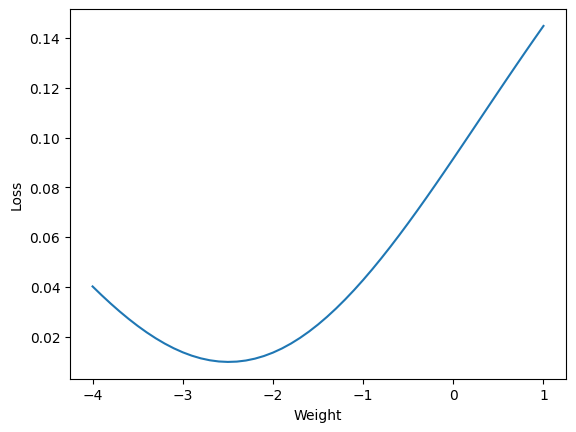

In [14]:
e = 2.71
num_list = [0.5,0.2,0.3,0.4,0.6]
num_neuron = 5
weight_list = [0.9,0.12,0.23,0.34,0.12]
w_past = []
loss_past = []
target = [0.6,0.4,0.34,0.42,0.56]
def sigmoid(a):
  return 1 / (1 + e ** (-a))



def forward_pass(num_neuron,num_list,weight_list):
    layer_output = []
    neuron_weights = []

    for i in range(num_neuron):

        weight = []
        result = 0

        for b,x in zip(num_list,weight_list):

            weight.append(x)
            result += x * b

        neuron_weights.append(weight)
        bias = 0.8
        z = result + bias
        activation = sigmoid(z)
        layer_output.append(activation)


    return layer_output

result =forward_pass(num_neuron,num_list,weight_list)

def loss(prediction,target):

     cost = 0
     for i in range(len(target)):

       cost += (target[i] - prediction[i])**2 / len(target)
     return cost


for u in range(-40,11):
            w = round(u * 0.1, 2)
            weight_list[0] = w
            result2 = forward_pass(num_neuron,num_list,weight_list)
            lost = loss(result2,target)
            w_past.append(w)
            loss_past.append(lost)
import matplotlib.pyplot as plt

plt.plot(w_past,loss_past)
plt.xlabel("Weight")
plt.ylabel("Loss")
plt.show()

# **SORU 5**

Bu kısım, en iyi ağırlığı elle aramak yerine bilgisayara otomatik buldurma yöntemi. Ağırlığı çok ufak miktarda artırıp azaltarak, hatanın hangi yöne gittiğini (artıyor mu azalıyor mu) hesaplıyoruz. Sonra ağırlığı hatayı azaltacak yöne doğru küçük adımlarla kaydırıyoruz. Bunu binlerce kez tekrarlayınca ağırlık, en düşük hataya sahip değere yaklaşıyor. Yapay zekanın "öğrenmesi" aslında bu mantığa dayanıyor.

In [15]:
w = 3
h = 0.001
learning_rate = 0.1
for i in range(5000):

  weight_list[0] = w + h
  pred_plus = forward_pass(num_neuron,num_list,weight_list)
  loss_plus = loss(pred_plus,target)
  weight_list[0] = w - h
  pred_minus = forward_pass(num_neuron,num_list,weight_list)
  loss_minus = loss(pred_minus,target)
  slope = (loss_plus - loss_minus) / (2*h)
  w_new = w - learning_rate * slope
  w = w_new
  if i > 4990:
    print(i,w)

4991 -2.4913772856875562
4992 -2.491377300936203
4993 -2.491377316137978
4994 -2.491377331293025
4995 -2.491377346401488
4996 -2.4913773614635097
4997 -2.4913773764792335
4998 -2.4913773914488013
4999 -2.4913774063723553
